Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Dataset Description:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     

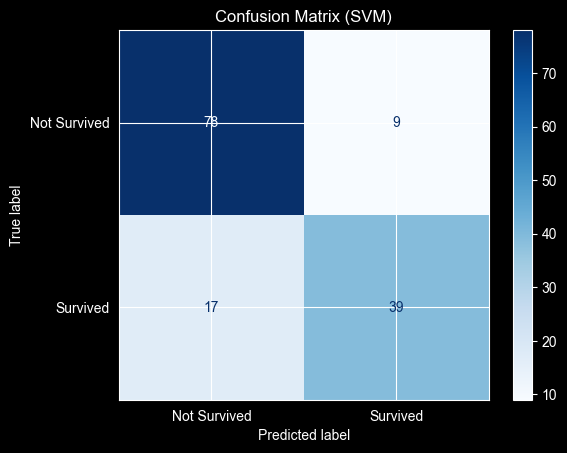

In [8]:
# Nikolas Reuter
# 1659144
# Big Data Analytics
# Project 2: Titanic Survivor Prediction using Support Vector Machine (SVM)

# Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the dataset
file_path = "Titanic-Dataset.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns
df = df.drop(columns=["PassengerId", "Ticket", "Cabin", "Name"])

# Encode categorical variables
label_encoders = {}
for column in ["Sex", "Embarked"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

# Drop missing values
print("\nShape before dropping NaN:", df.shape)
df = df.dropna()
print("Shape after dropping NaN:", df.shape)

# Define features (X) and target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Show used Features
print("\nFeatures used in the model:")
print(X.columns)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize / scale data (VERY important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SVM model
model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train model
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation (SVM):")
print("Accuracy Score:", accuracy)
print("Precision Score:", precision)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix (SVM)")
plt.show()